In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
"""Closed-form expression for Bayesian conjugate models"""

from typing import Optional
import numpy as np
import scipy as sp


def default_prior_params(prior: str, dim: int = 1) -> tuple:
    """Get the default prior parameters"""
    prior_params = ()
    if prior == "gamma":
        alpha_prior, beta_prior = 1, 1
        prior_params = (alpha_prior, beta_prior)
    elif prior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = 0.0, 1.0, 1.0, 1.0
        prior_params = (mu_prior, kappa_prior, alpha_prior, beta_prior)
    elif prior == "normal_inverse_wishart":
        prior_params = normal_inverse_wishart_prior(dim)
    else:
        raise NotImplementedError(f"Prior '{prior}' not implemented.")
    return prior_params


def get_posterior_params(
    posterior: str, data: np.ndarray, prior_params: tuple
) -> tuple:
    """Given prior parameters, return the updated posterior parameters"""
    post_params = []
    if posterior == "gamma":
        alpha_prior, beta_prior = prior_params
        alpha_posterior = alpha_prior + data.shape[0]
        beta_posterior = beta_prior + np.sum(data)
        post_params = (alpha_posterior, beta_posterior)
    elif posterior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = prior_params
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
        post_params = (mu_posterior, kappa_posterior, alpha_posterior, beta_posterior)
    elif posterior == "normal_inverse_wishart":
        post_params = normal_inverse_wishart_posterior(data, *prior_params)
    else:
        raise NotImplementedError(f"Posterior '{posterior}' is not implemented")
    return post_params


def derive_analytical_posterior_params(
    posterior: str, posterior_params: tuple
) -> np.ndarray:
    """When using our closed form expressions for 'Bayesian ambiguity sets',
    we derive a new distribution from the posterior parameters"""
    if posterior == "gamma":
        alpha_posterior, beta_posterior = posterior_params
        return np.array([alpha_posterior / beta_posterior])
    elif posterior == "normal_gamma":
        theta = np.zeros((1, 2))
        mu_posterior, _, alpha_posterior, beta_posterior = posterior_params
        # we want an analytical form for the precision, which is alpha over beta
        theta[0] = np.array([mu_posterior, alpha_posterior / beta_posterior])
        return theta
    elif posterior == "normal_inverse_wishart":
        mu_post, kappa_post, _, Psi_post = posterior_params
        Sigma_hat = 0.5 * np.linalg.inv(np.outer(mu_post, mu_post) - (1/kappa_post)*Psi_post)
        mu_hat = Sigma_hat @ mu_post
        return mu_hat, Sigma_hat
    else:
        raise NotImplementedError(
            f"We haven't derived an analytical posterior expression for a '{posterior}' posterior"
        )


def sample_posterior(
    posterior: str,
    posterior_params: tuple,
    num_posterior_samples: int,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample from the posterior"""
    if posterior == "gamma":
        alpha_post, beta_post = posterior_params
        return sp.stats.gamma.rvs(
            a=alpha_post,
            scale=1 / beta_post,
            size=num_posterior_samples,
            random_state=generator,
        )
    if posterior == "normal_gamma":
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = posterior_params
        return normal_gamma_rvs(
            num_posterior_samples,
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
            generator=generator,
        )
    else:
        raise NotImplementedError(f"Posterior '{posterior}' is not implemented")


def get_log_partition_constant(posterior: str, posterior_params: list) -> float:
    """Given the posterior params, return the optimization constant for Bayesian DRO"""
    if posterior == "gamma":
        alpha_posterior, _ = posterior_params
        return np.log(alpha_posterior) - sp.special.digamma(alpha_posterior)
    elif posterior == "normal_gamma":
        _, kappa_posterior, alpha_posterior, _ = posterior_params
        return get_normal_gamma_constant(alpha_posterior, kappa_posterior)
    else:
        raise NotImplementedError(f"get_log_partition_constant not implemented for posterior {posterior}")


def get_normal_gamma_constant(alpha: int, kappa: float) -> float:
    """Get the constant for normal-gamma DRO"""
    return 0.5 * (1 / kappa + np.log(alpha) - sp.special.digamma(alpha))


def normal_gamma_posterior(
    data: np.ndarray,
    mu_prior: float,
    kappa_prior: float,
    alpha_prior: float,
    beta_prior: float,
) -> tuple[float, float, float, float]:
    """Get the closed-form expression for normal-gamma posterior

    Returns:
        Posterior parameters for alpha, beta, mu, kappa

    Notes:
        See Section 3.3 of Murphy (2007).

    References:
        Murphy, K. P. (2007). Conjugate bayesian analysis of the gaussian distribution.
        Technical report, Department of Computer Science, The University of British Columbia.
    """
    num_observations = data.shape[0]
    data_mean = np.mean(data)
    mu_posterior = (kappa_prior * mu_prior + num_observations * data_mean) / (
        num_observations * kappa_prior
    )
    kappa_posterior = kappa_prior + num_observations
    alpha_posterior = alpha_prior + 0.5 * num_observations
    beta_posterior = (
        beta_prior
        + 0.5 * np.sum(np.square(data - data_mean))
        + (0.5 * num_observations * kappa_prior * np.square(data_mean - mu_prior))
        / (kappa_prior * num_observations)
    )
    return mu_posterior, kappa_posterior, alpha_posterior, beta_posterior


def normal_gamma_rvs(
    num_samples: int,
    mu: float,
    kappa: float,
    alpha: float,
    beta: float,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Normal-gamma random variates

    Notes:
        1. Sample precision `lambda` from a Gamma(`alpha`, `beta`) distribution
        2. Sample from a normal distribution with mean `mu` and standard deviation `sqrt(1/(kappa * lambda))`
    """
    samples = np.zeros((num_samples, 2))
    if not generator:
        generator = np.random.default_rng()
    precision_samples = generator.gamma(alpha, 1.0 / beta, num_samples)
    for i in range(num_samples):
        # NOTE numpy Normal distribution takes standard deviation as a parameter (hence sqrt) - not variance!
        samples[i, 0] = generator.normal(
            mu, np.sqrt(1.0 / (kappa * precision_samples[i])), 1
        )
    samples[:, 1] = precision_samples
    return samples

def normal_inverse_wishart_prior(dim: int):
    """Default normal-inverse-Wishart prior hyperparameters for D dimensions
    
    Args:
        D: dimension

Returns:
        mu: Prior mean. Vector with shape (D,)
        kappa: Reflects belief in prior mean (positive scalar)
        iota: Reflects belief in prior over covariance (positive scalar)
        Psi: matrix proportional to prior over covariance. Matrix with shape (D,D).
    """
    # since we derived our result via the exponential family, we set kappa = iota + D + 2
    iota = float(dim + 1)   # degrees of freedom must be greater than dim
    kappa = iota + dim + 2
    return np.zeros(dim), kappa, iota, 0.001* np.identity(dim)

def normal_inverse_wishart_posterior(data, mu_prior, kappa_prior, iota_prior, Psi_prior):
    """Normal-inverse-Wishart posterior hyperparameters for D dimensions

    Args:
        data: Observations with shape (N, D)
        mu: Prior mean. Vector with shape (D,)
        kappa: Reflects belief in prior mean (positive scalar)
        iota: Reflects belief in prior over covariance (positive scalar)
        Psi: matrix for prior over covariance. Matrix with shape (D,D).

    Returns:
        mu: Updated posterior mean. Vector with shape (D,)
        kappa: Updated belief in posterior mean (positive scalar)
        iota: Updated belief in posterior over covariance (positive scalar)
        Psi: Updated matrix for posterior over covariance. Matrix with shape (D,D).

    Notes:
        See Section 3.4.4.3 of Murphy (2023) Probabilistic Machine Learning: Advanced Topics.
    """
    N = data.shape[0]
    print(data.shape)
    print(mu_prior.shape)
    xi_mean = np.mean(data, axis=0)
    kappa_post = kappa_prior + N
    mu_post = (kappa_prior * mu_prior + N * xi_mean) / kappa_post
    iota_post = iota_prior + N
    # Psi update comes from eq. (3.172) of Murphy (see notes above)
    Psi_post = Psi_prior + data.T @ data + kappa_prior * np.outer(mu_prior, mu_prior) - kappa_post * np.outer(mu_post, mu_post)
    return mu_post, kappa_post, iota_post, Psi_post

def normal_inverse_wishart_samples(num_samples: int, mu: np.ndarray, kappa: float, iota: float, Psi: np.ndarray, generator: Optional[np.random.Generator] = None) -> tuple[np.ndarray, np.ndarray]:
    """Get N samples of mean and covariance from the normal-inverse-Wishart distribution.

    Args:
        num_samples: N for short
        mu: Mean hyperparameter. Vector with shape (D,)
        kappa: Positive scalar
        iota: Positive scalar
        Psi: Matrix with shape (D,D)
        generator: Numpy random number generator

    Returns:
        mu_samples: Matrix with shape (N,D)
        cov_samples: Tensor with shape (N,D,D)
    """
    dim = mu.shape[0]
    assert dim == Psi.shape[0] and dim == Psi.shape[1]

    # sample from the inverse Wishart
    iw_post = sp.stats.invwishart(iota, Psi, seed=generator)
    cov_samples = iw_post.rvs(num_samples)

    # sample from a multivariate normal given the covariance samples
    mu_samples = np.zeros((num_samples, dim))
    for i, cov in enumerate(cov_samples):
        mu_samples[i] = sp.stats.multivariate_normal(mu, 1/kappa * cov, seed=generator).rvs()
    assert mu_samples.shape == (num_samples, dim)
    assert cov_samples.shape == (num_samples, dim, dim)
    return mu_samples, cov_samples

def multivariate_digamma_p(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1-i)/2) for i in range(p)])

def get_normal_inverse_wishart_G_constant(mu_post: np.ndarray, kappa_post: float, Psi_post: np.ndarray) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    dim = mu_post.shape[0]
    Psi_inv = sp.linalg.inv(Psi_post)
    mu_Psi_inv_mu = mu_post.T @ Psi_inv @ mu_post
    term1 = 0.5 * np.log(np.linalg.det(np.outer(mu_post, mu_post) - (1 / kappa_post) * Psi_post))
    term2 = 0.25 * mu_Psi_inv_mu * ((kappa_post**2 * mu_Psi_inv_mu)/(1 - kappa_post * mu_Psi_inv_mu) - kappa_post + 2 * dim + 4)
    term3 = - 0.5 * multivariate_digamma_p(0.5 * (kappa_post - dim - 2), dim)
    term4 = dim/(2*kappa_post)
    term5 = np.log(np.linalg.det(Psi_post))
    return term1 + term2 + term3 + term4 + term5



In [3]:
replication = 3
generator = np.random.default_rng(replication)
dim = 5
num_observations = 20
prior_params = default_prior_params("normal_inverse_wishart", dim=dim)
mu_prior, kappa_prior, iota_prior, Psi_prior = prior_params

### Sample from the prior - visualise first two dimensions

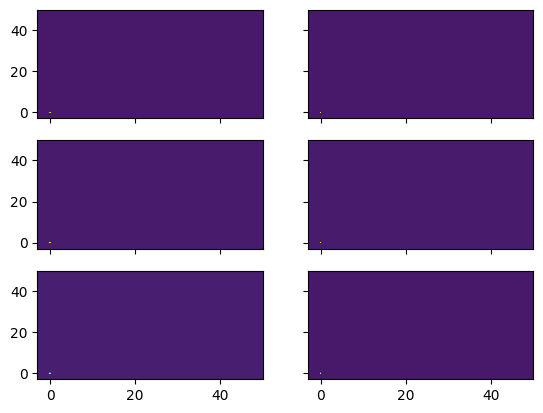

In [4]:

max_samples = 6
mu_prior_samples, cov_prior_samples = normal_inverse_wishart_samples(max_samples, mu_prior, kappa_prior, iota_prior, Psi_prior, generator=generator)


axis1, axis2 = np.mgrid[-3:50:0.1, -3:50:0.1]
fig, axes = plt.subplots(nrows=int(np.ceil(max_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(mu_prior_samples, cov_prior_samples)):
    if i >= max_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))



In [5]:
from typing import Optional
import numpy as np
from scipy.stats import expon, gamma, norm, multivariate_normal
from sklearn.datasets import make_spd_matrix

from bayesian_dro.Bayesian_DRO_continuous import data_generation, DGP_STD_TRUNCATED_NORMAL


# dgp_mean = np.array([1.0, -1.0])
# dgp_cov = np.array([[2.0, -0.5], [-0.5, 1.0]])

# dgp_mean = [10.0, 20.0, 30.0, 35.0, 22.0]
sklearn_cov_seed = 1
sklearn_random_state = np.random.RandomState(seed=sklearn_cov_seed)
cov_multiplier = 20.0
dgp_mean = [10.0, 20.0, 30.0, 35.0, 22.0]
dgp_cov = cov_multiplier * make_spd_matrix(dim, random_state=sklearn_random_state)


def sample_dgp(
    dgp: str,
    num_observations: int,
    contamination: float = 0.0,
    dim: int = 1,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample from the DGP"""
    if dgp == "multivariate_normal":
        return multivariate_normal.rvs(dgp_mean, dgp_cov, size=num_observations, random_state=generator)
    raise ValueError(f"The data-generating process specified is not supported: {dgp}")
dgp_cov


array([[ 28.04209142, -18.89185442, -15.09456034, -23.42025597,
          7.92300896],
       [-18.89185442,  31.68239015,  19.05366462,  33.48120513,
         -1.11980801],
       [-15.09456034,  19.05366462,  15.80944894,  23.51607492,
         -2.33497905],
       [-23.42025597,  33.48120513,  23.51607492,  60.86788088,
         -4.90517589],
       [  7.92300896,  -1.11980801,  -2.33497905,  -4.90517589,
          4.93176023]])

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/57280362.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


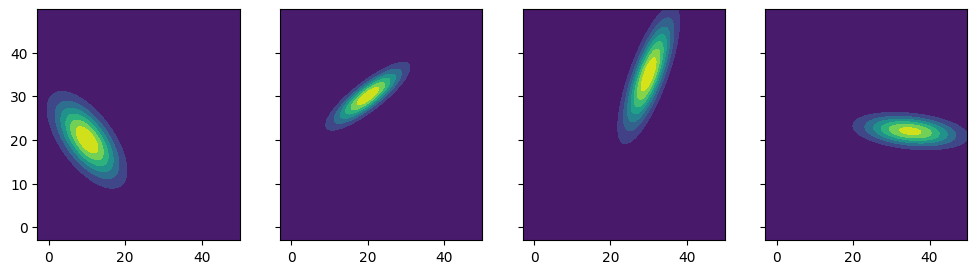

In [6]:
# visualise slices of the DGP
fig, axes = plt.subplots(ncols=dim-1, nrows=1, sharex=True, sharey=True, figsize=(12,3))
for d in range(dim-1):
    dgp_dist = sp.stats.multivariate_normal(dgp_mean[d:d+2], dgp_cov[d:d+2,d:d+2])
    axes[d].contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
fig.show()

In [7]:
# plot and sample from the DGP
xi = sample_dgp("multivariate_normal", num_observations, dim=dim)
xi_sum = np.sum(xi, axis=0)
xi_mean = np.mean(xi, axis=0)

In [8]:
post_params = get_posterior_params("normal_inverse_wishart", xi, prior_params)
mu_post, kappa_post, iota_post, Psi_post = post_params

(20, 5)
(5,)


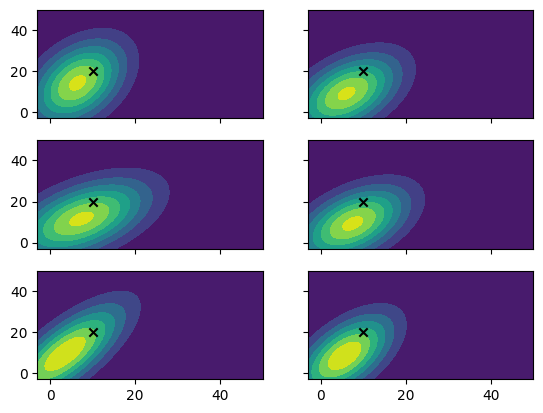

In [9]:
post_mu_samples, post_cov_samples = normal_inverse_wishart_samples(max_samples, *post_params, generator=generator)
axis1, axis2 = np.mgrid[-3:50:0.1, -3:50:0.1]
fig, axes = plt.subplots(nrows=int(np.ceil(max_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(post_mu_samples, post_cov_samples)):
    if i >= max_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))
    axes[int(i/ 2)][i%2].scatter(dgp_mean[0], dgp_mean[1], marker="x", color="black")

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/2424180084.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


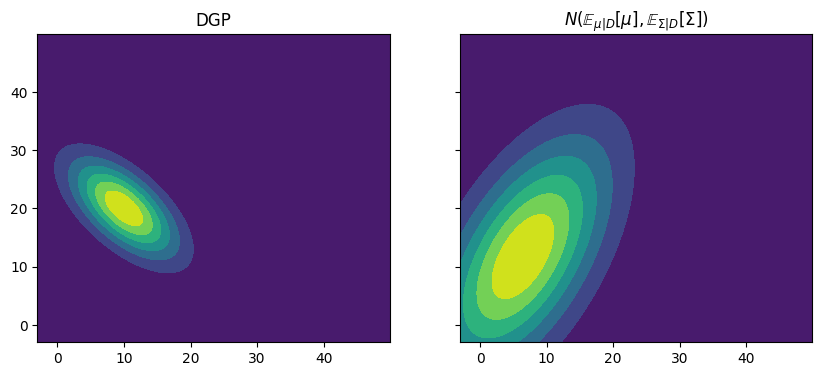

In [10]:
# plot expected Sigma next to DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)
dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_post[:2], expected_Sigma[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\mathbb{E}_{\mu | D}[\mu], \mathbb{E}_{\Sigma | D}[\Sigma])$")
fig.show()

### Plot $\mathcal{N}(\hat{\mu}, \hat{\Sigma})$ where $ \hat{\Sigma} = \frac{1}{2} \left(\overset{\frown}{\mu} \overset{\frown}{\mu}^\top - \overset{\frown}{\kappa}^{-1} \overset{\frown}{\Psi} \right)^{-1}$ and $\hat{\mu} = \hat{\Sigma} \overset{\frown}{\mu}$.


**Problem:** The matrix $\hat{\Sigma}$ is not PSD! The diagonals are negative!

In [11]:
Sigma_hat = (1/(kappa_post - dim - 2))*Psi_post
mu_hat = mu_post
Sigma_hat

array([[ 55.45479066,  50.55498114,  86.60708265,  98.47421706,
         76.55590979],
       [ 50.55498114, 135.46294751, 185.36856736, 224.07056654,
        131.52575298],
       [ 86.60708265, 185.36856736, 272.84999835, 320.08903614,
        198.87650025],
       [ 98.47421706, 224.07056654, 320.08903614, 391.84506352,
        230.90933686],
       [ 76.55590979, 131.52575298, 198.87650025, 230.90933686,
        153.25916841]])

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/2734676859.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


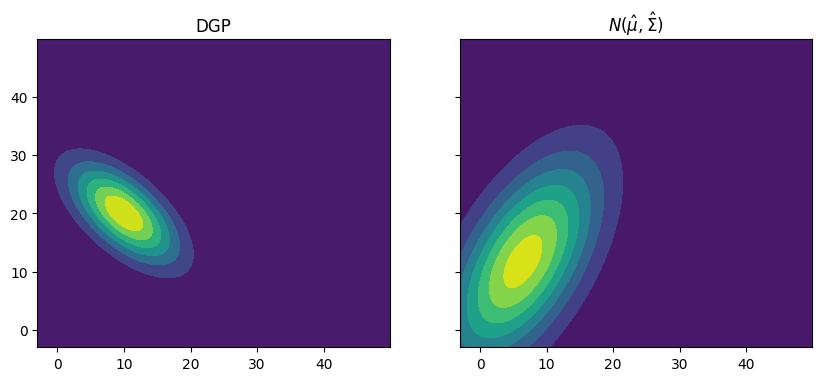

In [14]:
# plot hat{Sigma} next to the DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))



# mu_hat, Sigma_hat = derive_analytical_posterior_params("normal_inverse_wishart", post_params)

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\hat{\mu}, \hat{\Sigma})$")
fig.show()

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/4102054644.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


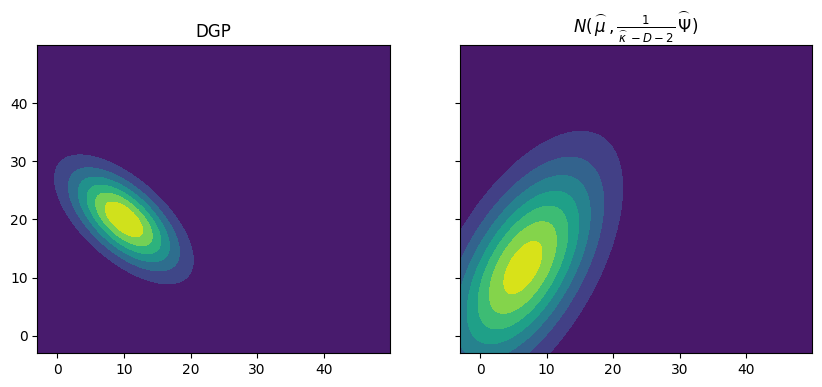

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))

Sigma_hat = (1/(kappa_post - dim - 2))*Psi_post
# Sigma_hat = (1/(iota_post))*Psi_post

mu_hat =  mu_post

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa} - D - 2} \overset{\frown}{\Psi})$")
fig.show()

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_48086/169037416.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


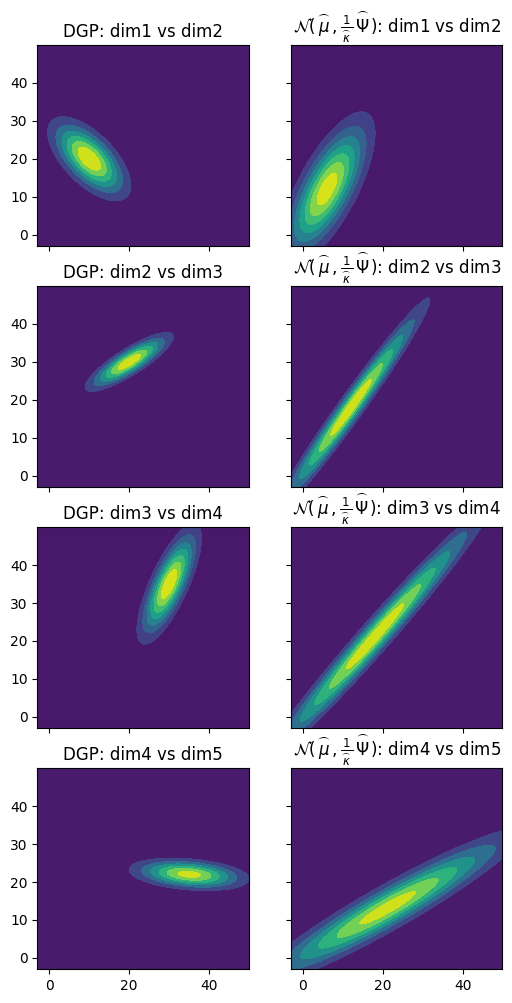

In [ ]:
# visualise slices of the DGP
fig, axes = plt.subplots(ncols=2, nrows=dim-1, sharex=True, sharey=True, figsize=(6,12))
for d in range(dim-1):
    dgp_dist = sp.stats.multivariate_normal(dgp_mean[d:d+2], dgp_cov[d:d+2,d:d+2])
    axes[d][0].contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][0].set_title(f"DGP: dim{d+1} vs dim{d+2}")
    sad_dist = sp.stats.multivariate_normal(mu_hat[d:d+2], Sigma_hat[d:d+2,d:d+2], seed=generator)
    axes[d][1].contourf(axis1, axis2, sad_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][1].set_title(r"$\mathcal{N}(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa}} \overset{\frown}{\Psi})$: " + f"dim{d+1} vs dim{d+2}")
fig.show()